<a href="https://colab.research.google.com/github/muhammadalibutt20/Emotional-Speech/blob/main/Emotional_Speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import os
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
import io
from google.colab import files

# Ensure resampy is available for librosa

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Path to dataset files: /kaggle/input/ravdess-emotional-speech-audio


In [4]:
!pip install resampy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.0 MB/s eta 0:00:00


### 1. Feature Extraction
We will extract 40 MFCCs from each audio file. For the Random Forest, we use the mean of MFCCs. For the LSTM, we will keep the sequence information.

In [5]:
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import os
import pandas as pd

def extract_features(file_path, max_pad_len=400):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    except:
        audio, sample_rate = librosa.load(file_path)

    # Extract MFCCs
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

    # Add Deltas and Delta-Deltas to capture transitions
    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)

    # Stack features: (120, time_steps)
    combined = np.concatenate((mfccs, delta_mfccs, delta2_mfccs), axis=0)

    # Padding/Truncating
    if (combined.shape[1] < max_pad_len):
        pad_width = max_pad_len - combined.shape[1]
        combined = np.pad(combined, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        combined = combined[:, :max_pad_len]

    return combined

# Define the path to the dataset (obtained from previous cell)
# 'path' variable is available from the kernel state.
data_dir = path # Use the 'path' variable from kagglehub download

# Map emotion codes to labels
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Create a DataFrame with file paths and emotions
filepaths = []
emotions = []

for directory in os.listdir(data_dir):
    actor_path = os.path.join(data_dir, directory)
    if os.path.isdir(actor_path):
        for filename in os.listdir(actor_path):
            if filename.endswith('.wav'):
                filepaths.append(os.path.join(actor_path, filename))
                # Extract emotion from filename (e.g., '03-01-01-01-01-01-01.wav' -> '01' for emotion)
                emotion_code = filename.split('-')[2] # Third part is emotion code
                emotions.append(emotion_map.get(emotion_code, 'unknown'))

df = pd.DataFrame({'filepath': filepaths, 'emotion': emotions})

print("Extracting enhanced features (MFCC + Deltas)...")
X_enhanced = np.array([extract_features(f) for f in df['filepath']])

# Scaling across the sequence
num_samples, num_features, time_steps = X_enhanced.shape
X_reshaped = X_enhanced.reshape(-1, num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped).reshape(num_samples, num_features, time_steps)

le = LabelEncoder()
y_encoded = le.fit_transform(df['emotion'])

# Split
X_train_seq, X_test_seq, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Reshape for CNN-LSTM: (samples, time_steps, features)
X_train_lstm = X_train_seq.transpose(0, 2, 1)
X_test_lstm = X_test_seq.transpose(0, 2, 1)

# For RF, use the mean of the 40 original MFCCs for simplicity
X_rf = np.mean(X_scaled[:, :40, :], axis=2)
X_train_rf, X_test_rf, _, _ = train_test_split(X_rf, y_encoded, test_size=0.2, random_state=42)
print("Features ready.")

Extracting enhanced features (MFCC + Deltas)...
Features ready.


In [6]:
# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_rf, y_train)
rf_preds = rf_model.predict(X_test_rf)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.6667


In [7]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

# Hybrid CNN-LSTM Architecture
def build_optimized_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),

        # CNN layers to extract spatial features from MFCCs
        Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),

        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),

        # LSTM to process the downsampled sequence
        LSTM(128, return_sequences=False),
        Dropout(0.4),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])
lstm_model = build_optimized_model(model_input_shape, len(le.classes_))

# Lower learning rate for fine-grained optimization
optimizer = Adam(learning_rate=0.0005)
lstm_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

print("Training Optimized CNN-LSTM Hybrid...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_test_lstm, y_test),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Training Optimized CNN-LSTM Hybrid...
Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 397ms/step - accuracy: 0.0946 - loss: 2.8852 - val_accuracy: 0.1597 - val_loss: 2.0781 - learning_rate: 5.0000e-04
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.1181 - loss: 2.5928 - val_accuracy: 0.1528 - val_loss: 2.0734 - learning_rate: 5.0000e-04
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.1493 - loss: 2.4365 - val_accuracy: 0.1493 - val_loss: 2.0799 - learning_rate: 5.0000e-04
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.1580 - loss: 2.2886 - val_accuracy: 0.1528 - val_loss: 2.0735 - learning_rate: 5.0000e-04
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.2135 - loss: 2.1232 - val_accuracy: 0.1493 - val_loss: 2.1141 - learning_rate: 5.0000e-04
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.2465 - loss: 2.0357 - val_accuracy: 0.1562 - val_loss: 2.1375 - learning_rate: 5.0000e-04
Epoch 7/10
36/36 ━━━━━━━━

In [11]:
import io
import google.colab.files
import librosa
import numpy as np
import os # Import os module for path operations

def predict_uploaded_audio(model, label_encoder, scaler_obj):
    uploaded = google.colab.files.upload()

    for filename in uploaded.keys():
        # Check if the uploaded file is an audio file
        if not filename.lower().endswith(('.wav', '.mp3', '.ogg', '.flac')):
            print(f"Skipping '{filename}': Not a recognized audio file format. Please upload an audio file (e.g., .wav, .mp3).")
            continue # Skip to the next file

        try:
            audio, sr = librosa.load(filename, res_type='kaiser_fast')
        except Exception as e:
            print(f"Error loading audio file '{filename}': {e}")
            continue

        # Must match the training feature extraction (120 features)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        delta_mfccs = librosa.feature.delta(mfccs)
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)
        combined = np.concatenate((mfccs, delta_mfccs, delta2_mfccs), axis=0)

        max_pad_len = 400
        if (combined.shape[1] < max_pad_len):
            pad_width = max_pad_len - combined.shape[1]
            combined = np.pad(combined, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            combined = combined[:, :max_pad_len]

        # Scale features: shape must be (400, 120) for transform
        combined_reshaped = combined.T
        combined_scaled = scaler_obj.transform(combined_reshaped)

        # Reshape for CNN-LSTM: (1, 400, 120)
        input_data = combined_scaled[np.newaxis, ...]

        prediction = model.predict(input_data)
        predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])

        print(f'\nResult for {filename}:')
        print(f'Detected Emotion: {predicted_label[0].upper()}')

# Run with the optimized model and scaler
predict_uploaded_audio(lstm_model, le, scaler)

Saving WhatsApp Ptt 2026-07-03 at 3.13.24 PM.ogg to WhatsApp Ptt 2026-07-03 at 3.13.24 PM.ogg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step

Result for WhatsApp Ptt 2026-07-03 at 3.13.24 PM.ogg:
Detected Emotion: CALM


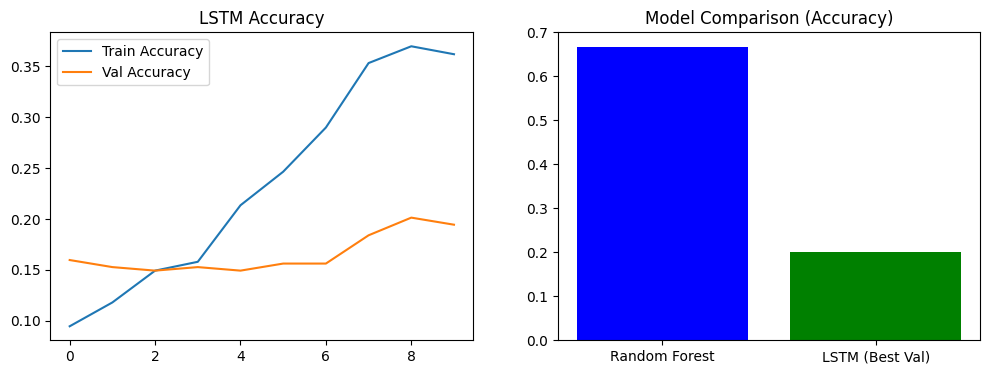

In [9]:
# Compare Results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(['Random Forest', 'LSTM (Best Val)'], [rf_acc, max(history.history['val_accuracy'])], color=['blue', 'green'])
plt.title('Model Comparison (Accuracy)')
plt.show()

### 3. Comprehensive Performance Visualization
We will plot the learning curves for the LSTM model and look at the detailed metrics for the Random Forest classifier.

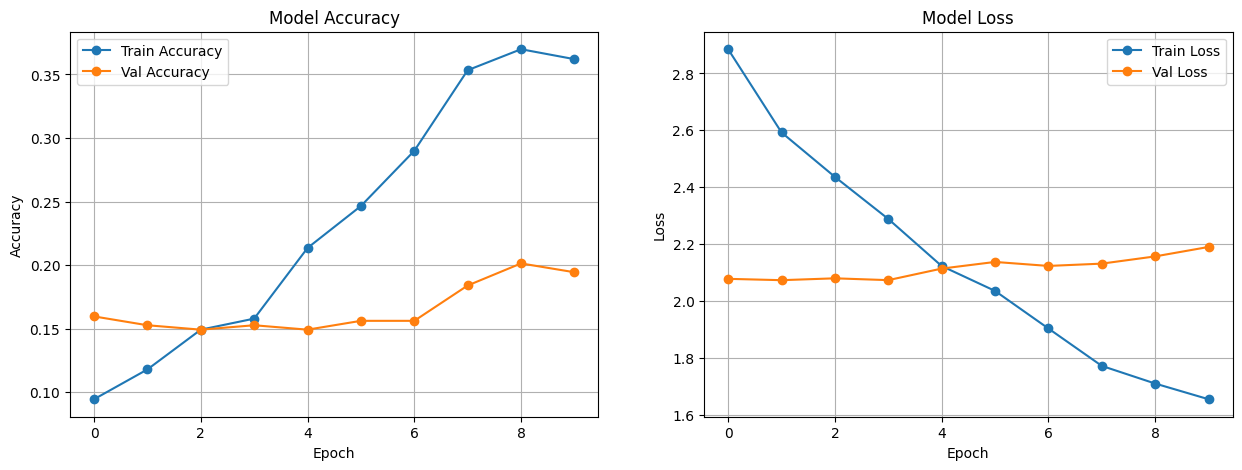

Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

       angry       0.86      0.74      0.79        34
        calm       0.61      0.90      0.73        40
     disgust       0.81      0.64      0.72        45
     fearful       0.61      0.71      0.66        31
       happy       0.69      0.59      0.63        41
     neutral       0.60      0.47      0.53        19
         sad       0.47      0.46      0.46        35
   surprised       0.70      0.72      0.71        43

    accuracy                           0.67       288
   macro avg       0.67      0.65      0.65       288
weighted avg       0.68      0.67      0.66       288



In [10]:
def plot_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy Plot
    axs[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    axs[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
    axs[0].set_title('Model Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()
    axs[0].grid(True)

    # Loss Plot
    axs[1].plot(history.history['loss'], label='Train Loss', marker='o')
    axs[1].plot(history.history['val_loss'], label='Val Loss', marker='o')
    axs[1].set_title('Model Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid(True)

    plt.show()

# Visualize the LSTM training progress
if 'history' in globals():
    plot_history(history)

# Detailed report for Random Forest
print("Detailed Classification Report (Random Forest):")
print(classification_report(y_test, rf_preds, target_names=le.classes_))